# Imports

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA as skPCA
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.metrics.cluster import adjusted_rand_score

In [77]:
# import dataframes. Names = df + max date of orders
df_7 = pd.read_csv('data/customers_2016-09-04_2018-10-17.csv')
df_6 = pd.read_csv('data/customers_2016-09-04_2018-08-17.csv')
df_5 = pd.read_csv('data/customers_2016-09-04_2018-06-17.csv')
df_4 = pd.read_csv('data/customers_2016-09-04_2018-04-17.csv')
df_3 = pd.read_csv('data/customers_2016-09-04_2018-02-17.csv')
df_2 = pd.read_csv('data/customers_2016-09-04_2017-12-17.csv')
df_1 = pd.read_csv('data/customers_2016-09-04_2017-10-17.csv')

In [78]:
print(df_7.shape)
print(df_6.shape)
print(df_5.shape)
print(df_4.shape)
print(df_3.shape)
print(df_2.shape)
print(df_1.shape)

(94700, 15)
(93127, 15)
(79835, 15)
(67011, 15)
(53663, 15)
(41324, 15)
(28621, 15)


# Select the same unique points / customer_unique_id

In [ ]:
# Use customer_unique_id from the older dataset as the basis / filter for the future datasets

In [95]:
def transform_df(transform_df, base_df, col):
    transform_df = transform_df[transform_df[col].isin(base_df[col])].sort_values(by=col).set_index(col)
    #transform_df = transform_df[transform_df[col].isin(base_df[col])].sort_values(by=col).set_index(col).reset_index(drop=True)
    
    return transform_df

In [98]:
df_7 = transform_df(df_7, df_1, 'customer_unique_id')
df_6 = transform_df(df_6, df_1, 'customer_unique_id')
df_5 = transform_df(df_5, df_1, 'customer_unique_id')
df_4 = transform_df(df_4, df_1, 'customer_unique_id')
df_3 = transform_df(df_3, df_1, 'customer_unique_id')
df_2 = transform_df(df_2, df_1, 'customer_unique_id')
df_1 = transform_df(df_1, df_1, 'customer_unique_id')

In [99]:
print(df_7.shape)
print(df_6.shape)
print(df_5.shape)
print(df_4.shape)
print(df_3.shape)
print(df_2.shape)
print(df_1.shape)

(28621, 14)
(28621, 14)
(28621, 14)
(28621, 14)
(28621, 14)
(28621, 14)
(28621, 14)


In [100]:
df_1.head()

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
customer_unique_id,,,,,,,,,,,,,,
0000f46a3911fa3c0805444483337064,221,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,69.0,17.22,0,4,0.0
0000f6ccb0745a6a4b88665a16c9f078,5,0.0,0.0,0.0,0.0,0.0,0.0,25.99,0.0,0.0,17.63,0,5,100.0
0005e1862207bf6ccc02e4228effd9a0,227,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,135.0,15.12,0,4,0.0
0006fdc98a402fceb4eb0ee528f6a8d4,91,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,15.10,0,1,100.0
000a5ad9c4601d2bbdd9ed765d5213b3,67,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,14.29,1,4,0.0


# train kmeans_8 all datasets


In [147]:
skewness = df_1.select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)


Colonnes numériques avec une skewness supérieure à la limite :
['baby', 'computers', 'fixed_telephony', 'furniture_decor', 'musical_instruments', 'sports_leisure', 'telephony', 'toys', 'other_categories', 'freight_value']
['recency', 'frequency_medium', 'mean_review_score', 'ratio_comment_message']


In [148]:
def customTransform(df, cols_skewed, cols_unskewed):
    # sélection colonnes avec skewness élevée :
    
    # Création du ColumnTransformer
    transformer = ColumnTransformer([
        #('minmax', MinMaxScaler(), cols_skewed),
        ('power', PowerTransformer(), cols_skewed),
        ('standard', StandardScaler(), cols_unskewed)
    ])
    
    X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
    return X_std

In [150]:
X_7 = customTransform(df_7, cols_skewed, cols_unskewed)
X_6 = customTransform(df_6, cols_skewed, cols_unskewed)
X_5 = customTransform(df_5, cols_skewed, cols_unskewed)
X_4 = customTransform(df_4, cols_skewed, cols_unskewed)
X_3 = customTransform(df_3, cols_skewed, cols_unskewed)
X_2 = customTransform(df_2, cols_skewed, cols_unskewed)
X_1 = customTransform(df_1, cols_skewed, cols_unskewed)

In [151]:
print(X_7.shape)
print(X_6.shape)
print(X_5.shape)
print(X_4.shape)
print(X_3.shape)
print(X_2.shape)
print(X_1.shape)

(28621, 14)
(28621, 14)
(28621, 14)
(28621, 14)
(28621, 14)
(28621, 14)
(28621, 14)


## Check training first dataset

In [145]:
X_1.head()

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
0,-0.17185,-0.05393,-0.063792,-0.286994,-0.073311,-0.302057,-0.219799,-0.233766,1.869734,-0.111998,1.306800,-0.669877,-0.090125,-0.860951
1,-0.17185,-0.05393,-0.063792,-0.286994,-0.073311,-0.302057,4.549617,-0.233766,-0.537311,-0.063104,-1.422303,-0.669877,0.672583,1.167715
2,-0.17185,-0.05393,-0.063792,-0.286994,-0.073311,-0.302057,-0.219799,-0.233766,1.891437,-0.389753,1.382608,-0.669877,-0.090125,-0.860951
3,-0.17185,-0.05393,-0.063792,-0.286994,-0.073311,-0.302057,-0.219799,-0.233766,-0.537311,-0.392645,-0.335715,-0.669877,-2.378249,1.167715
4,-0.17185,-0.05393,-0.063792,-0.286994,-0.073311,-0.302057,-0.219799,-0.233766,-0.537311,-0.514331,-0.638949,1.425484,-0.090125,-0.860951


BatchKmeans 2 clusters, sil score : 0.11589480282487974
BatchKmeans 3 clusters, sil score : 0.15926560259213104
BatchKmeans 4 clusters, sil score : 0.15843207802195752
BatchKmeans 5 clusters, sil score : 0.14174759864321707
BatchKmeans 6 clusters, sil score : 0.19542064914616764
BatchKmeans 7 clusters, sil score : 0.2201722426733922
BatchKmeans 8 clusters, sil score : 0.2008458211474061
BatchKmeans 9 clusters, sil score : 0.23615271708288582
BatchKmeans 10 clusters, sil score : 0.1801815388037426
BatchKmeans 11 clusters, sil score : 0.21289301950582265
BatchKmeans 12 clusters, sil score : 0.2517200166771631
BatchKmeans 13 clusters, sil score : 0.246492211826188
BatchKmeans 14 clusters, sil score : 0.24252113897929967
BatchKmeans 15 clusters, sil score : 0.22186418372916092


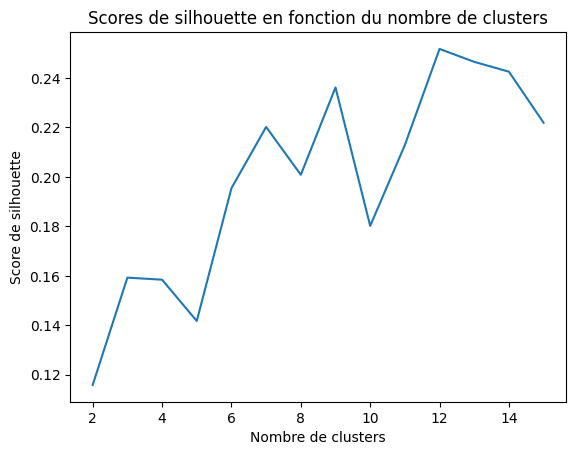

Le nombre optimal de clusters est : 12


In [146]:
X_std = X_1.copy()

# Calcul du score de silhouette pour chaque valeur de n_clusters comprise entre 2 et 15
n_clusters_range = range(2, 16)
scores = []

columns = X_std.columns

for n_clusters in n_clusters_range:
    # Initialisation de KMeans avec kmeans++
    
    #kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=42)
    #kmeans.fit(X_std)
    #labels = kmeans.labels_
    #score = silhouette_score(X_std, labels)
    #print(f'Kmeans sil score : {score}')
    #scores.append(score)

    # Initialisation de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, batch_size=100, random_state=42)
    mbkmeans.fit(X_std)
    labels_mb = mbkmeans.labels_
    score_mb = silhouette_score(X_std, labels_mb)
    print(f'BatchKmeans {n_clusters} clusters, sil score : {score_mb}')
    scores.append(score_mb)

# Tracé du graphique des scores de silhouette
plt.plot(n_clusters_range, scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Scores de silhouette en fonction du nombre de clusters')
plt.show()

# Sélection de la valeur de n_clusters qui donne le score de silhouette le plus élevé
best_score = max(scores)
best_index = scores.index(best_score)
best_n_clusters = best_index + 2

print(f"Le nombre optimal de clusters est : {best_n_clusters}")

### Train and compare through time

In [164]:
clusters_num = 12

kmeans_X_7 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_7)
kmeans_X_6 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_6)
kmeans_X_5 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_5)
kmeans_X_4 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_4)
kmeans_X_3 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_3)
kmeans_X_2 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_2)
kmeans_X_1 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_1)

Initialization complete
Iteration 0, inertia 196724.14577732183.
Iteration 1, inertia 153246.40832546007.
Iteration 2, inertia 149931.73213557337.
Iteration 3, inertia 146895.07301195717.
Iteration 4, inertia 145024.8358601367.
Iteration 5, inertia 144657.76050384087.
Iteration 6, inertia 144620.7352919393.
Iteration 7, inertia 144560.0815470994.
Iteration 8, inertia 144438.58365415674.
Iteration 9, inertia 144325.90925958377.
Iteration 10, inertia 144260.59040897712.
Iteration 11, inertia 144256.52711476237.
Iteration 12, inertia 144256.43081935693.
Converged at iteration 12: strict convergence.
Initialization complete
Iteration 0, inertia 206483.39732318593.
Iteration 1, inertia 131683.94275396902.
Iteration 2, inertia 128636.02983384313.
Iteration 3, inertia 128162.06311161788.
Iteration 4, inertia 127984.96727304041.
Iteration 5, inertia 127860.14176428471.
Iteration 6, inertia 127762.11610810619.
Iteration 7, inertia 127696.83852884761.
Iteration 8, inertia 127642.15359392276.
Ite

# Compute ARI

In [165]:
ari0 = adjusted_rand_score(kmeans_X_1.labels_, kmeans_X_1.labels_)
ari1 = adjusted_rand_score(kmeans_X_2.labels_, kmeans_X_1.labels_)
ari2 = adjusted_rand_score(kmeans_X_3.labels_, kmeans_X_1.labels_)
ari3 = adjusted_rand_score(kmeans_X_4.labels_, kmeans_X_1.labels_)
ari4 = adjusted_rand_score(kmeans_X_5.labels_, kmeans_X_1.labels_)
ari5 = adjusted_rand_score(kmeans_X_6.labels_, kmeans_X_1.labels_)
ari6 = adjusted_rand_score(kmeans_X_7.labels_, kmeans_X_1.labels_)

In [166]:
scores = [ari0, ari1, ari2, ari3, ari4, ari5, ari6]
periodes = ['Période 0', 'Période 1', 'Période 2', 'Période 3', 'Période 4', 'Période 5', 'Période 6']

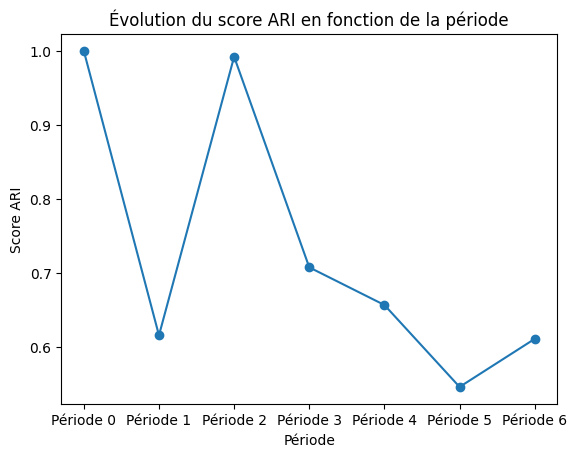

In [167]:
plt.plot(periodes, scores, marker='o')
plt.xlabel('Période')
plt.ylabel('Score ARI')
plt.title('Évolution du score ARI en fonction de la période')
plt.show()